In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/shl-intern-hiring-assessment/Dataset/sample_submission.csv
/kaggle/input/shl-intern-hiring-assessment/Dataset/train.csv
/kaggle/input/shl-intern-hiring-assessment/Dataset/test.csv
/kaggle/input/shl-intern-hiring-assessment/Dataset/audios/test/audio_885.wav
/kaggle/input/shl-intern-hiring-assessment/Dataset/audios/test/audio_1142.wav
/kaggle/input/shl-intern-hiring-assessment/Dataset/audios/test/audio_1006.wav
/kaggle/input/shl-intern-hiring-assessment/Dataset/audios/test/audio_817.wav
/kaggle/input/shl-intern-hiring-assessment/Dataset/audios/test/audio_765.wav
/kaggle/input/shl-intern-hiring-assessment/Dataset/audios/test/audio_508.wav
/kaggle/input/shl-intern-hiring-assessment/Dataset/audios/test/audio_257.wav
/kaggle/input/shl-intern-hiring-assessment/Dataset/audios/test/audio_330.wav
/kaggle/input/shl-intern-hiring-assessment/Dataset/audios/test/audio_72.wav
/kaggle/input/shl-intern-hiring-assessment/Dataset/audios/test/audio_328.wav
/kaggle/input/shl-intern-hiring-ass

# Data Analysis(Statistical Insights) and EDA on Scores only.

****Loading the .csv files****

In [3]:
import pandas as pd


train_df = pd.read_csv('/kaggle/input/shl-intern-hiring-assessment/Dataset/train.csv')
test_df = pd.read_csv('/kaggle/input/shl-intern-hiring-assessment/Dataset/test.csv')
sample_sub = pd.read_csv('/kaggle/input/shl-intern-hiring-assessment/Dataset/sample_submission.csv')


print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()


Train shape: (444, 2)
Test shape: (204, 1)


,filename,label
0,audio_710.wav,1.0
1,audio_1265.wav,1.0
2,audio_1114.wav,1.5
3,audio_946.wav,1.5
4,audio_1127.wav,2.0


In [4]:
train_df[train_df['filename']=='audio_859.wav']

,filename,label
83,audio_859.wav,3.0


In [5]:
test_df.head()

,filename
0,audio_804.wav
1,audio_1028.wav
2,audio_865.wav
3,audio_774.wav
4,audio_1138.wav


In [6]:
sample_sub.head()

,filename,label
0,audio_804.wav,-1
1,audio_1028.wav,-1
2,audio_865.wav,-1
3,audio_774.wav,-1
4,audio_1138.wav,-1


****Train.csv(Grammar Score Stats)****

In [7]:
print("Grammar Score Summary:")
print(train_df['label'].describe())


Grammar Score Summary:
count    444.000000
mean       3.967342
std        1.048784
min        1.000000
25%        3.000000
50%        4.000000
75%        5.000000
max        5.000000
Name: label, dtype: float64


In [8]:
from scipy.stats import skew, kurtosis

print(f"Skewness of label: {skew(train_df['label']):.2f}")
print(f"Kurtosis of label: {kurtosis(train_df['label']):.2f}")



Skewness of label: -0.73
Kurtosis of label: -0.70


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


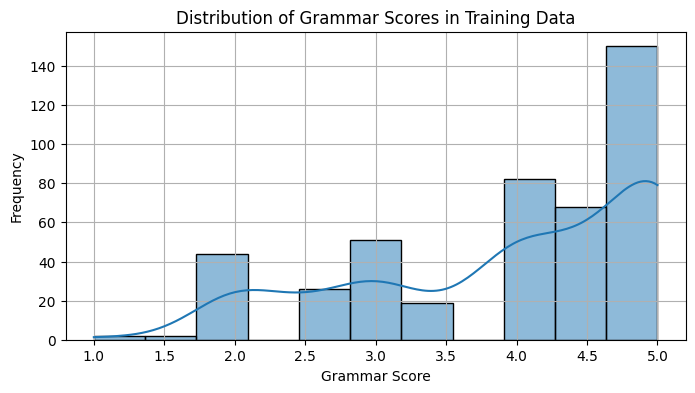

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(train_df['label'], bins=11, kde=True)
plt.title("Distribution of Grammar Scores in Training Data")
plt.xlabel("Grammar Score")
plt.ylabel("Frequency")
plt.grid()
plt.show()


In [10]:
!pip install git+https://github.com/openai/whisper.git
!apt install ffmpeg


  Cloning https://github.com/openai/whisper.git to /tmp/pip-req-build-8eyyt_oh
  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git /tmp/pip-req-build-8eyyt_oh
  Resolved https://github.com/openai/whisper.git to commit 517a43ecd132a2089d85f4ebc044728a71d49f6e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━

# Audio Preprocessing like Trimming, normalize volume(better ASR Performance), resampling to 16kHz

In [11]:
import librosa
import soundfile as sf
import os
from tqdm import tqdm

def preprocess_audio(input_path, output_path, target_sr=16000):
    
    y, sr = librosa.load(input_path, sr=None)

   
    y_resampled = librosa.resample(y, orig_sr=sr, target_sr=target_sr)

 
    y_trimmed, _ = librosa.effects.trim(y_resampled, top_db=20)

 
    y_normalized = librosa.util.normalize(y_trimmed)

    
    sf.write(output_path, y_normalized, target_sr)


def batch_preprocess(input_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    for file in tqdm(os.listdir(input_dir)):
        if file.endswith(".wav"):
            preprocess_audio(
                input_path=os.path.join(input_dir, file),
                output_path=os.path.join(output_dir, file)
            )


batch_preprocess("/kaggle/input/shl-intern-hiring-assessment/Dataset/audios/train", "processed_audio/train/")
batch_preprocess("/kaggle/input/shl-intern-hiring-assessment/Dataset/audios/test", "processed_audio/test/")


100%|██████████| 204/204 [01:24<00:00,  2.41it/s]


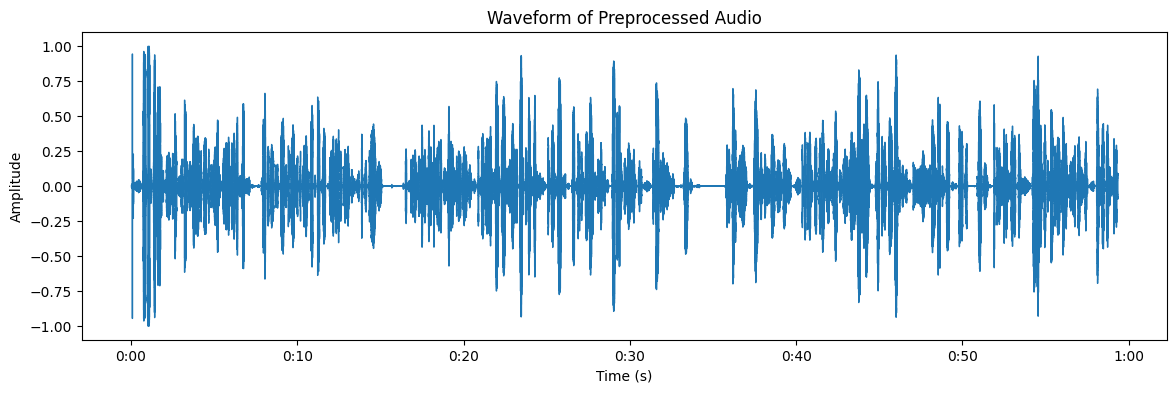

In [12]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Load one preprocessed audio file (example from train)
audio_path = "/kaggle/working/processed_audio/train/audio_1002.wav"  # Replace with actual filename
y, sr = librosa.load(audio_path, sr=None)

# Plot the waveform
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform of Preprocessed Audio")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()


# Transcribing the cleaned audio using whisper

In [13]:
import whisper
import os
import pandas as pd
from tqdm.notebook import tqdm


In [14]:
AUDIO_PATH = "/kaggle/working/processed_audio/train/"

model = whisper.load_model("base") 

def transcribe_audio(file_name):
    try:
        result = model.transcribe(os.path.join(AUDIO_PATH, file_name))
        return result['text']
    except Exception as e:
        print(f"Error transcribing {file_name}: {e}")
        return ""


100%|████████████████████████████████████████| 139M/139M [00:01<00:00, 129MiB/s]
/usr/local/lib/python3.11/dist-packages/whisper/__init__.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this exper

In [15]:
transcripts = []

for file_name in tqdm(train_df["filename"]):  
    text = transcribe_audio(file_name)
    transcripts.append(text)

train_df["transcript"] = transcripts
train_df.to_csv("/kaggle/working/train_with_transcripts.csv", index=False)


  0%|          | 0/444 [00:00<?, ?it/s]

In [16]:
missing_files = train_df[train_df["transcript"].isna()]["filename"]

for file_name in tqdm(missing_files):
    text = transcribe_audio(file_name)
    train_df.loc[train_df["filename"] == file_name, "transcript"] = text


0it [00:00, ?it/s]

# Feature Extraction and their Correlation

In [17]:

!pip install -q spacy
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 63.9 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [18]:
!pip install textstat



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.3/105.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.4/939.4 kB 20.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 54.3 MB/s eta 0:00:00:00:01


In [19]:
import pandas as pd

train_df = pd.read_csv("/kaggle/working/train_with_transcripts.csv")
train_df.head()


,filename,label,transcript
0,audio_710.wav,1.0,﹗ご家﹗ そボール apparent ڈلسு میں ہے ۔ ۔ ۔ ۔ ۔ ۔ ۔...
1,audio_1265.wav,1.0,My favorite hobby is cultivation of plants su...
2,audio_1114.wav,1.5,vy boswalap musilod believed Afghan program ro...
3,audio_946.wav,1.5,the playground looks like very clear and neat...
4,audio_1127.wav,2.0,My goal is to bring my parents to live with m...


In [20]:
train_df[train_df['filename']=='audio_859.wav']

,filename,label,transcript
83,audio_859.wav,3.0,NaN


In [21]:
null_rows = train_df[train_df['transcript'].isnull()]
print(null_rows[['filename']])


           filename
23    audio_921.wav
83    audio_859.wav
87    audio_151.wav
116   audio_387.wav
123  audio_1159.wav
141   audio_575.wav
165   audio_491.wav
176    audio_58.wav
196   audio_583.wav
209   audio_127.wav
220   audio_474.wav
244   audio_385.wav
261   audio_586.wav
299   audio_259.wav
314   audio_655.wav
326   audio_370.wav
345   audio_512.wav
361   audio_707.wav
396   audio_514.wav
408    audio_43.wav


In [22]:

train_df = train_df.dropna(subset=['transcript']).reset_index(drop=True)


In [23]:
train_df[train_df["transcript"].isna()]


,filename,label,transcript


****Data Cleaning****

In [24]:


train_df['transcript'].shape

import re

def clean_transcript(text):
    
    text = text.lower()

   
    fillers = ['uh', 'um', 'you know', 'like', 'i mean', 'so', 'well']
    filler_pattern = r'\b(?:' + '|'.join(re.escape(f) for f in fillers) + r')\b'
    text = re.sub(filler_pattern, '', text)

   
    text = re.sub(r'\s+', ' ', text)              
    text = re.sub(r'\s([?.!,"])', r'\1', text)     
    text = re.sub(r'([?.!,"])\s*', r'\1 ', text)   
    text = text.strip()

    return text


train_df['clean_transcript'] = train_df['transcript'].apply(clean_transcript)

train_df.to_csv("/kaggle/working/train_cleaned.csv", index=False)




In [25]:
!pip install language-tool-python



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 3.3 MB/s eta 0:00:00


 ****This below code is for feature extraction using language tool and spacy for local Environment as language_tool_python needs java --version >=17.0.0 but Kaggle has 11.0.0, Online API also has limitaions for free use -  20 requests per minute, 75,000 characters per minute, 20,000 characters per request.****

In [26]:
# import pandas as pd
# import spacy
# from tqdm import tqdm
# import language_tool_python

# # Load spaCy model and local LanguageTool
# nlp = spacy.load("en_core_web_sm")
# tool = language_tool_python.LanguageTool('en-US')  # local tool, faster

# # Load CSV
# df = pd.read_csv("/home/hp/Desktop/shl/train_cleaned.csv")  # Local path, same directory

# # Setup tqdm with pandas
# tqdm.pandas()

# # Define your transcript column
# TEXT_COLUMN = "clean_transcript"

# # Feature extraction using local LanguageTool and spaCy
# def extract_features(text):
#     try:
#         matches = tool.check(text)
#     except Exception as e:
#         print(f"LanguageTool error: {e}")
#         matches = []

#     total_errors = len(matches)

#     # Run spaCy once on full text
#     doc = nlp(text)
#     pos_counts = doc.count_by(spacy.attrs.POS)
#     total_tokens = len(doc)

#     return pd.Series([
#         total_errors,
#         total_errors / (len(text.split()) + 1e-5),
#         pos_counts.get(91, 0) / total_tokens,   # NOUN
#         pos_counts.get(100, 0) / total_tokens,  # VERB
#         pos_counts.get(84, 0) / total_tokens,   # ADJ
#         pos_counts.get(85, 0) / total_tokens,   # ADV
#         len(list(doc.sents)),
#         total_tokens
#     ])

# # Feature column names
# feature_cols = [
#     "num_errors", "error_density", "noun_ratio", "verb_ratio",
#     "adj_ratio", "adv_ratio", "sent_count", "word_count"
# ]

# # Apply with progress
# df_features = df[TEXT_COLUMN].progress_apply(extract_features)
# df_features.columns = feature_cols

# # Save the result locally
# df_combined = pd.concat([df, df_features], axis=1)
# df_combined.to_csv("train_with_features.csv", index=False)


In [27]:


train_df = pd.read_csv("/kaggle/input/train-feature/train_with_features.csv")

train_df.head()


,filename,label,transcript,clean_transcript,num_errors,error_density,noun_ratio,verb_ratio,adj_ratio,adv_ratio,sent_count,word_count,subj_verb_errors,article_errors,punctuation_errors,flesch_reading,gunning_fog,smog_index
0,audio_710.wav,1.0,sardbraadesh நீ깨 அது என்று தெல்லுது இங்கோடுத்...,sardbraadesh நீ깨 அது என்று தெல்லுது இங்கோடுத்த...,1.0,0.032258,0.0,0.064516,0.064516,0.000000,1.0,31.0,0.0,0.0,0.0,90.77,12.40,0.0
1,audio_1265.wav,1.0,My favorite hobby is cultivation of plants su...,my favorite hobby is cultivation of plants suc...,3.0,0.096774,0.0,0.090909,0.121212,0.121212,2.0,33.0,0.0,0.0,0.0,64.20,10.07,0.0
2,audio_1114.wav,1.5,My Girl is to become an electrical employee ....,my girl is to become an electrical employee. a...,5.0,0.250000,0.0,0.090909,0.045455,0.045455,2.0,22.0,0.0,0.0,0.0,27.49,18.00,0.0
3,audio_946.wav,1.5,the playground looks like very clear and neat...,the playground looks very clear and neat as th...,1.0,0.052632,0.0,0.100000,0.150000,0.050000,1.0,20.0,0.0,0.0,0.0,77.57,9.71,0.0
4,audio_1127.wav,2.0,My goal is to bring my parents to live with m...,my goal is to bring my parents to live with me...,15.0,0.130435,0.0,0.120301,0.037594,0.090226,11.0,133.0,0.0,0.0,0.0,86.20,6.29,8.3


In [ ]:
feature_cols = [
    "num_errors", "error_density", "noun_ratio", "verb_ratio",
    "adj_ratio", "adv_ratio", "sent_count", "word_count", 
    "subj_verb_errors",	"article_errors", "punctuation_errors",	"flesch_reading", "gunning_fog", "smog_index"
]



sns.pairplot(train_df[["label"] + feature_cols], kind='reg', plot_kws={"line_kws":{'color':'red'}})
plt.suptitle("Correlation of Features with Grammar Score", y=1.02)
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

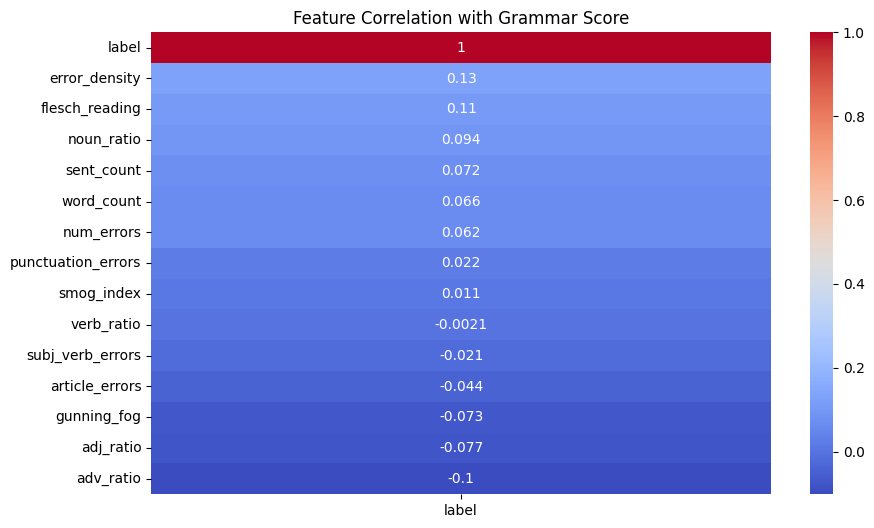

In [29]:
plt.figure(figsize=(10, 6))
corr = train_df[feature_cols + ["label"]].corr()
sns.heatmap(corr[["label"]].sort_values(by="label", ascending=False), annot=True, cmap="coolwarm")
plt.title("Feature Correlation with Grammar Score")
plt.show()


****Insights from Feature Correlation Heatmap****

1. Weak overall correlation: Most handcrafted features have a weak correlation with the grammar score (label). This         indicates that while these features offer useful signals, they may not be sufficient alone to predict the score          accurately.   

2. Top positively correlated features:
   error_density (+0.13): Mild positive correlation; might indicate that high scorers make frequent but minor errors        (possibly due to self-correction or fluency).   

   flesch_reading (+0.11): Easier-to-read text tends to score better grammatically, suggesting fluent speakers may use      simpler, well-structured language.

   noun_ratio (+0.094): Higher noun usage slightly correlates with better grammar scores, possibly due to more              structured sentence construction. 

3. Sentence and word count:

   sent_count and word_count show slightly positive correlations, suggesting that longer and more elaborate responses       may reflect stronger grammar control.

4. Negatively correlated features:

   gunning_fog, smog_index (readability complexity indices) show negative correlation, implying that overly complex or      verbose text does not align well with high grammar scores.

   subj_verb_errors, article_errors, adv_ratio, and adj_ratio also show negative correlations, which aligns with            expectations — more grammatical issues reduce the overall grammar quality.      
  
5. Takeaway for modeling:

   Despite weak correlations individually, these features can provide complementary insights when combined with deep        contextual embeddings (like BERT). 

   Useful for model interpretability and possibly improving generalization when fused into a hybrid model.



****Training and Validation with BERT-uncased and XG_boost on concatenate embeddings(BERT+Extracted_Features)****

In [30]:
import os
import pandas as pd
import numpy as np
import torch
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr
import xgboost as xgb


In [31]:
train_df_bert= pd.read_csv('/kaggle/working/train_cleaned.csv')
train_df_bert.drop(['transcript'], axis=1, inplace= True)

train_df_bert.head()

,filename,label,clean_transcript
0,audio_710.wav,1.0,﹗ご家﹗ そボール apparent ڈلسு میں ہے ۔ ۔ ۔ ۔ ۔ ۔ ۔ ۔...
1,audio_1265.wav,1.0,my favorite hobby is cultivation of plants suc...
2,audio_1114.wav,1.5,vy boswalap musilod believed afghan program ro...
3,audio_946.wav,1.5,the playground looks very clear and neat as th...
4,audio_1127.wav,2.0,my goal is to bring my parents to live with me...


In [32]:
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
)

2025-04-23 14:14:10.956757: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745417651.143377      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745417651.200268      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [33]:
TEXT_COL  = "clean_transcript"
LABEL_COL = "label"

In [34]:

train_df, valid_df = train_test_split(train_df_bert, test_size=0.2, random_state=42)



In [56]:
 

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model_bert     = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=1,               
)


class RegressionDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts    = texts.tolist()
        self.labels   = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len  = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        enc = self.tokenizer(
            self.texts[i],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[i], dtype=torch.float),
        }

train_ds = RegressionDataset(train_df[TEXT_COL], train_df[LABEL_COL], tokenizer)
valid_ds = RegressionDataset(valid_df[TEXT_COL], valid_df[LABEL_COL], tokenizer)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [57]:

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    preds = preds.flatten()
    mae = mean_absolute_error(labels, preds)
    pearson_corr = pearsonr(labels, preds)[0]
    return {"mae": mae, "pearson": pearson_corr}


training_args = TrainingArguments(
    output_dir="./bert_regressor",
    do_train=True,
    do_eval=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=7,
    learning_rate=2e-5,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="mae",
    greater_is_better=False,
    report_to="none",
)


In [58]:

trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    compute_metrics=compute_metrics,
)
trainer.train()


Epoch,Training Loss,Validation Loss,Mae,Pearson
1,No log,1.481868,1.086169,-0.088244
2,No log,1.157646,0.890438,0.549172
3,3.532100,0.892533,0.689006,0.656455
4,3.532100,0.841855,0.670599,0.688951
5,0.570200,0.783627,0.625205,0.683392
6,0.570200,0.653614,0.566492,0.720243
7,0.302900,0.713418,0.589541,0.713230


TrainOutput(global_step=154, training_loss=1.4367770003033924, metrics={'train_runtime': 62.1085, 'train_samples_per_second': 38.207, 'train_steps_per_second': 2.48, 'total_flos': 156089232117504.0, 'train_loss': 1.4367770003033924, 'epoch': 7.0})

In [61]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_bert.to(device).eval()

def get_cls_embeddings(texts):
    embs = []
    with torch.no_grad():
        for t in tqdm(texts, desc="Embedding"):
            enc = tokenizer(
                t, padding="max_length", truncation=True, max_length=128, return_tensors="pt"
            ).to(device)
            out = model_bert(**enc, output_hidden_states=True, return_dict=True)
            cls = out.hidden_states[-1][:, 0, :].cpu().numpy()
            embs.append(cls)
    return np.vstack(embs)

X_bert_train = get_cls_embeddings(train_df[TEXT_COL])
X_bert_valid = get_cls_embeddings(valid_df[TEXT_COL])


Embedding:   0%|          | 0/339 [00:00<?, ?it/s]

Embedding:   0%|          | 0/85 [00:00<?, ?it/s]

In [39]:
feat_train=pd.read_csv('/kaggle/input/train-feature/train_with_features.csv')

feat_train, feat_valid = train_test_split(feat_train, test_size=0.2, random_state=42)


In [40]:


X_train = np.hstack([X_bert_train, feat_train[feature_cols].values])
X_valid = np.hstack([X_bert_valid, feat_valid[feature_cols].values])

y_train = train_df[LABEL_COL].values
y_valid = valid_df[LABEL_COL].values


In [41]:

xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    tree_method="gpu_hist" if torch.cuda.is_available() else "hist",
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    early_stopping_rounds=50,
    verbose=50,
)


print('XGB Trained')

/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [14:15:39] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


[0]	validation_0-rmse:1.11481
[50]	validation_0-rmse:0.85748
[100]	validation_0-rmse:0.85765
[107]	validation_0-rmse:0.85785
XGB Trained


In [42]:

y_pred = xgb_model.predict(X_valid)
rmse         = np.sqrt(mean_squared_error(y_valid, y_pred))
pearson_corr = pearsonr(y_valid, y_pred)[0]

print(f"→ XGB RMSE: {rmse:.4f}")
print(f"→ XGB Pearson: {pearson_corr:.4f}")

→ XGB RMSE: 0.8545
→ XGB Pearson: 0.6607


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [14:15:39] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


# ON TEST SET

In [43]:
test_df=pd.read_csv('/kaggle/input/shl-intern-hiring-assessment/Dataset/test.csv')

In [44]:
AUDIO_PATH= '/kaggle/working/processed_audio/test'
model = whisper.load_model("base") 
transcripts_test=[]

for file_name in tqdm(test_df["filename"]):  
    text = transcribe_audio(file_name)
    transcripts_test.append(text)

test_df["transcript"] = transcripts_test
test_df.to_csv("/kaggle/working/test_with_transcripts.csv", index=False)

/usr/local/lib/python3.11/dist-packages/whisper/__init__.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(fp, map_location=device)


  0%|          | 0/204 [00:00<?, ?it/s]

In [45]:
test_df.head()

,filename,transcript
0,audio_804.wav,My hobbies are playing cricket because I am a...
1,audio_1028.wav,My favorite place is in Andhra Padesh. It is ...
2,audio_865.wav,"Yeah, my best days in my life is recently I g..."
3,audio_774.wav,Actually the most I use it to enjoy is like p...
4,audio_1138.wav,I would like to become a beauty unit. Among t...


In [46]:
test_df['transcript'].head()

0     My hobbies are playing cricket because I am a...
1     My favorite place is in Andhra Padesh. It is ...
2     Yeah, my best days in my life is recently I g...
3     Actually the most I use it to enjoy is like p...
4     I would like to become a beauty unit. Among t...
Name: transcript, dtype: object

In [47]:
test_null_rows= test_df[test_df['transcript'].isnull()]
test_null_rows

,filename,transcript


In [48]:
test_df['clean_transcript'] = test_df['transcript'].apply(clean_transcript)

test_df.to_csv("/kaggle/working/test_cleaned.csv", index=False)

In [49]:
test_df=pd.read_csv('/kaggle/working/test_cleaned.csv')

In [50]:
test_df.isnull().sum()

filename            0
transcript          4
clean_transcript    4
dtype: int64

In [53]:
Text_col='clean_transcript'

In [62]:
test_bert_embeddings = get_cls_embeddings(
    test_df[Text_col].fillna("")
)



Embedding:   0%|          | 0/204 [00:00<?, ?it/s]

In [63]:
feat_test=pd.read_csv('/kaggle/input/test-features/test_with_features.csv')

In [65]:


X_test= np.hstack([test_bert_embeddings, feat_test[feature_cols].values])





In [66]:
Y_pred= xgb_model.predict(X_test)

In [74]:
test_df=pd.read_csv('/kaggle/input/shl-intern-hiring-assessment/Dataset/test.csv')

In [75]:
submission = pd.DataFrame({
    "filename":  test_df["filename"],  
    "label": Y_pred             
})

submission.to_csv("submission.csv", index=False)
print(submission.head())
print("submission.csv saved with correct column order.")


         filename     label
0   audio_804.wav  4.175819
1  audio_1028.wav  4.195637
2   audio_865.wav  4.180747
3   audio_774.wav  4.129680
4  audio_1138.wav  4.205710
submission.csv saved with correct column order.
